# **5-Shapes-Circle,Triangle,Square,Hexagon,Pentagon**
The dataset consists of images of different sizes and colours of all these shapes. Data is generated using **Turtle** library in Python.



# SVM Model

In [ ]:
import cv2
import os
import numpy as np
from sklearn import svm
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from joblib import dump, load
from skimage.feature import hog

# Paths and parameters
image_folder = '/content/drive/MyDrive/smaller datasize'
img_size = 60
shape_classes = ['circle', 'hexagon', 'pentagon', 'square', 'triangle']
class_labels = {name: index for index, name in enumerate(shape_classes)}

# Data and labels
data = []
labels = []

## Feature extraction functions

# HOG feature extraction
def extract_hog_features(image):
    gray_img = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return hog(gray_img, pixels_per_cell=(8, 8), cells_per_block=(2, 2), block_norm='L2-Hys')

# ORB feature extraction (alternative to SURF)
def extract_orb_features(image):
    gray_img = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    orb = cv2.ORB_create()
    keypoints, descriptors = orb.detectAndCompute(gray_img, None)

    if descriptors is not None:
        return np.mean(descriptors, axis=0)
    else:
        return np.zeros(32)

# Color Histogram extraction
def extract_color_histogram(image):
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    hist_hue = cv2.calcHist([hsv], [0], None, [256], [0, 256])
    hist_saturation = cv2.calcHist([hsv], [1], None, [256], [0, 256])
    hist_value = cv2.calcHist([hsv], [2], None, [256], [0, 256])

    hist_hue /= hist_hue.sum()
    hist_saturation /= hist_saturation.sum()
    hist_value /= hist_value.sum()

    return hist_hue.flatten(), hist_saturation.flatten(), hist_value.flatten()

# Data augmentation: Rotation and flipping
def augment_image(image):
    augmented_images = []

    # Rotate the image at 90 degrees
    rotated_90_img = cv2.rotate(image, cv2.ROTATE_90_CLOCKWISE)
    augmented_images.append(rotated_90_img)

    # Rotate the image at 270 degrees
    rotated_270_img = cv2.rotate(image, cv2.ROTATE_90_COUNTERCLOCKWISE)
    augmented_images.append(rotated_270_img)

    # Horizontal Flip - one flip
    flipped_img = cv2.flip(image, 1)
    augmented_images.append(flipped_img)

    return augmented_images

# Load images, resize, and extract features
for shape_class in shape_classes:
    shape_folder = os.path.join(image_folder, shape_class)
    for filename in os.listdir(shape_folder):
        if filename.endswith(".png") or filename.endswith(".jpg"):
            img_path = os.path.join(shape_folder, filename)
            img = cv2.imread(img_path)
            img = cv2.resize(img, (img_size, img_size))

            # Augment the image
            augmented_images = augment_image(img)

            for augmented_img in augmented_images:
                # Extract features from HOG, ORB, and Color Histograms
                hog_features = extract_hog_features(augmented_img)
                orb_features = extract_orb_features(augmented_img)
                hist_hue, hist_saturation, hist_value = extract_color_histogram(augmented_img)

                # Combine all features into one vector
                combined_features = np.concatenate([hog_features, orb_features, hist_hue, hist_saturation, hist_value])

                data.append(combined_features)
                labels.append(class_labels[shape_class])

# Convert lists to NumPy arrays
data = np.array(data)
labels = np.array(labels)

# Standardize features
scaler = StandardScaler()
data = scaler.fit_transform(data)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

# Train SVM model with RBF kernel
svm_model = svm.SVC(kernel='rbf', C=1.0, gamma='scale', probability=True)  # Set probability=True for ROC curve
svm_model.fit(X_train, y_train)

# Evaluate the model
y_pred = svm_model.predict(X_test)

# Print classification report
print(classification_report(y_test, y_pred, target_names=shape_classes))

# Calculate overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Overall Accuracy: {accuracy * 100:.2f}%')

# Save the SVM model and scaler
dump(svm_model, '/content/drive/MyDrive/svm_shape_model_with_reduced_features.joblib')
dump(scaler, '/content/drive/MyDrive/scaler_with_reduced_features.joblib')


              precision    recall  f1-score   support

      circle       0.94      0.89      0.92       190
     hexagon       0.87      0.84      0.86       180
    pentagon       0.95      0.86      0.91       172
      square       0.89      0.90      0.90       171
    triangle       0.82      0.95      0.88       187

    accuracy                           0.89       900
   macro avg       0.90      0.89      0.89       900
weighted avg       0.90      0.89      0.89       900

Overall Accuracy: 89.11%


['/content/drive/MyDrive/scaler_with_reduced_features.joblib']

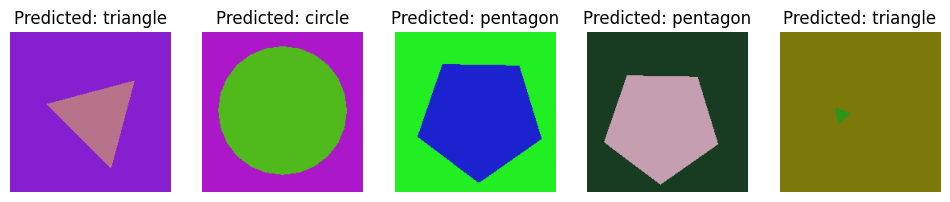

In [ ]:
import os
import random
import cv2
import numpy as np
import matplotlib.pyplot as plt


# Load the trained SVM model and scaler
svm_model = load('/content/drive/MyDrive/svm_shape_model_with_reduced_features.joblib')
scaler = load('/content/drive/MyDrive/scaler_with_reduced_features.joblib')

# Define shape classes
shape_classes = ['circle', 'hexagon', 'pentagon', 'square', 'triangle']

# Function to extract features
def extract_hog_features(image):
    gray_img = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return hog(gray_img, pixels_per_cell=(8, 8), cells_per_block=(2, 2), block_norm='L2-Hys')

def extract_orb_features(image):
    gray_img = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    orb = cv2.ORB_create()
    keypoints, descriptors = orb.detectAndCompute(gray_img, None)
    if descriptors is not None:
        return np.mean(descriptors, axis=0)
    else:
        return np.zeros(32)

def extract_color_histogram(image):
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    hist_hue = cv2.calcHist([hsv], [0], None, [256], [0, 256])
    hist_saturation = cv2.calcHist([hsv], [1], None, [256], [0, 256])
    hist_value = cv2.calcHist([hsv], [2], None, [256], [0, 256])
    hist_hue /= hist_hue.sum()
    hist_saturation /= hist_saturation.sum()
    hist_value /= hist_value.sum()
    return hist_hue.flatten(), hist_saturation.flatten(), hist_value.flatten()

# Function to automatically pick up some example images from the validation dataset
def get_example_images(validation_folder, num_examples=5):
    image_paths = []
    # Traverse the validation folder and get image paths
    for shape_class in shape_classes:
        shape_folder = os.path.join(validation_folder, shape_class)
        if os.path.exists(shape_folder):
            images = [os.path.join(shape_folder, img) for img in os.listdir(shape_folder) if img.endswith(('.png', '.jpg', '.jpeg'))]
            image_paths.extend(images)

    # Randomly select `num_examples` images from the list
    random.shuffle(image_paths)
    return image_paths[:num_examples]

# Define function to predict and display images
def predict_and_display(image_paths, shape_classes):
    plt.figure(figsize=(12, 8))

    for i, image_path in enumerate(image_paths):
        # Load and preprocess the image
        img = cv2.imread(image_path)

        # Check if the image was loaded correctly
        if img is None:
            print(f"Error: Unable to load image at path {image_path}")
            continue

        img_resized = cv2.resize(img, (img_size, img_size))

        # Extract features using the same methods as in training
        hog_features = extract_hog_features(img_resized)
        orb_features = extract_orb_features(img_resized)
        hist_hue, hist_saturation, hist_value = extract_color_histogram(img_resized)

        # Combine features
        combined_features = np.concatenate([hog_features, orb_features, hist_hue, hist_saturation, hist_value])

        # Standardize features using the previously fitted scaler
        standardized_features = scaler.transform([combined_features])

        # Predict shape class
        prediction = svm_model.predict(standardized_features)[0]
        predicted_label = shape_classes[prediction]

        # Display the image with the prediction
        plt.subplot(1, len(image_paths), i + 1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(f'Predicted: {predicted_label}')
        plt.axis('off')

    plt.show()

# Example usage
validation_folder = '/content/drive/MyDrive/smaller datasize'  # Replace with the path to your validation dataset
example_images = get_example_images(validation_folder, num_examples=5)
predict_and_display(example_images, shape_classes)


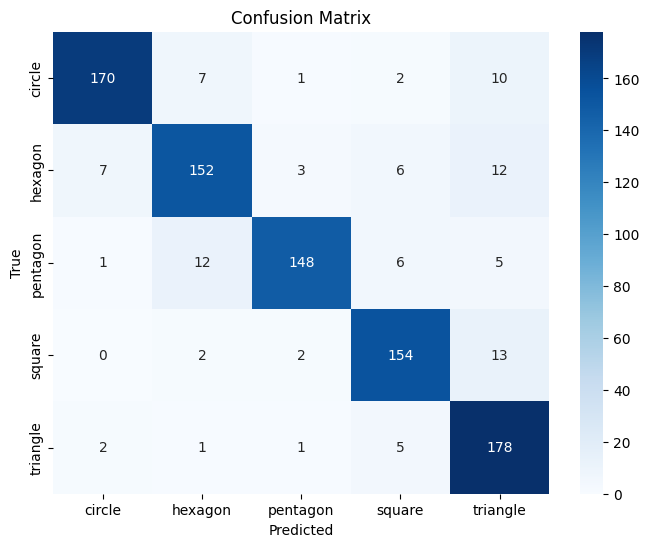

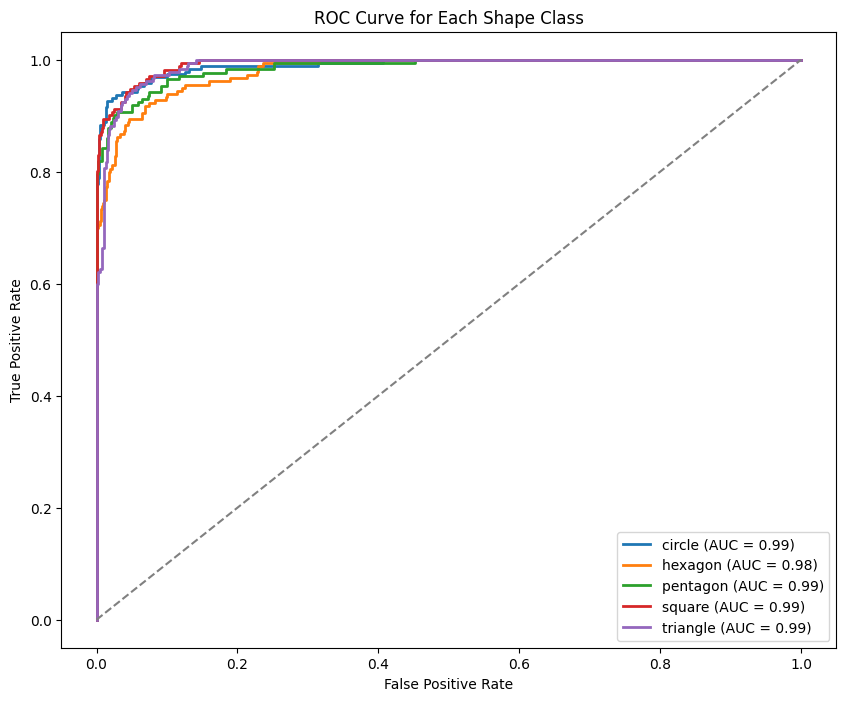

In [ ]:
from sklearn.metrics import confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=shape_classes, yticklabels=shape_classes)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Binarize the labels for multiclass ROC curve
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3, 4])  # Adjust classes if necessary
y_pred_prob = svm_model.predict_proba(X_test)

# Compute ROC curve and ROC area for each class
fpr = {}
tpr = {}
roc_auc = {}

plt.figure(figsize=(10, 8))

for i, shape in enumerate(shape_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], lw=2, label=f'{shape} (AUC = {roc_auc[i]:.2f})')

# Plot ROC curve details
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal for reference
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Each Shape Class')
plt.legend(loc='lower right')
plt.show()


# Random Forest

In [ ]:
import cv2
import os
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from joblib import dump, load
from skimage.feature import hog

# Paths and parameters
image_folder = '/content/drive/MyDrive/smaller datasize'
img_size = 60
shape_classes = ['circle', 'hexagon', 'pentagon', 'square', 'triangle']
class_labels = {name: index for index, name in enumerate(shape_classes)}

# Data and labels
data = []
labels = []

## Feature extraction functions

# HOG feature extraction
def extract_hog_features(image):
    gray_img = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return hog(gray_img, pixels_per_cell=(8, 8), cells_per_block=(2, 2), block_norm='L2-Hys')

# ORB feature extraction (alternative to SURF)
def extract_orb_features(image):
    gray_img = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    orb = cv2.ORB_create()
    keypoints, descriptors = orb.detectAndCompute(gray_img, None)

    if descriptors is not None:
        return np.mean(descriptors, axis=0)
    else:
        return np.zeros(32)

# Color Histogram extraction
def extract_color_histogram(image):
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    hist_hue = cv2.calcHist([hsv], [0], None, [256], [0, 256])
    hist_saturation = cv2.calcHist([hsv], [1], None, [256], [0, 256])
    hist_value = cv2.calcHist([hsv], [2], None, [256], [0, 256])

    hist_hue /= hist_hue.sum()
    hist_saturation /= hist_saturation.sum()
    hist_value /= hist_value.sum()

    return hist_hue.flatten(), hist_saturation.flatten(), hist_value.flatten()

# Data augmentation
def augment_image(image):
    augmented_images = []

    # Rotate the image at multiple angles (e.g., 90, 180, 270 degrees)
    rotated_90_img = cv2.rotate(image, cv2.ROTATE_90_CLOCKWISE)
    augmented_images.append(rotated_90_img)

    rotated_180_img = cv2.rotate(image, cv2.ROTATE_180)
    augmented_images.append(rotated_180_img)

    rotated_270_img = cv2.rotate(image, cv2.ROTATE_90_COUNTERCLOCKWISE)
    augmented_images.append(rotated_270_img)

    # Horizontal Flip - one flip
    flipped_img = cv2.flip(image, 1)
    augmented_images.append(flipped_img)

    return augmented_images

# Load images, resize, and extract features
for shape_class in shape_classes:
    shape_folder = os.path.join(image_folder, shape_class)
    for filename in os.listdir(shape_folder):
        if filename.endswith(".png") or filename.endswith(".jpg"):
            img_path = os.path.join(shape_folder, filename)
            img = cv2.imread(img_path)
            img = cv2.resize(img, (img_size, img_size))

            # Augment the image (now with fewer augmentations)
            augmented_images = augment_image(img)

            for augmented_img in augmented_images:
                # Extract features from HOG, ORB, and Color Histograms
                hog_features = extract_hog_features(augmented_img)
                orb_features = extract_orb_features(augmented_img)
                hist_hue, hist_saturation, hist_value = extract_color_histogram(augmented_img)

                # Combine all features into one vector
                combined_features = np.concatenate([hog_features, orb_features, hist_hue, hist_saturation, hist_value])

                data.append(combined_features)
                labels.append(class_labels[shape_class])

# Convert lists to NumPy arrays
data = np.array(data)
labels = np.array(labels)

# Standardize features
scaler = StandardScaler()
data = scaler.fit_transform(data)

# Compute class weights to handle class imbalance
class_weights = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
class_weight_dict = dict(zip(np.unique(labels), class_weights))

# Split the data
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

# Train Random Forest model with class weights
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight=class_weight_dict)
random_forest_model.fit(X_train, y_train)

# Evaluate the model
y_pred = random_forest_model.predict(X_test)

# Print classification report
print("Classification Report:\n")
print(classification_report(y_test, y_pred, target_names=shape_classes))

# Calculate overall accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Overall Accuracy: {accuracy * 100:.2f}%')

# Cross-validation for more reliable accuracy estimation
cv_scores = cross_val_score(random_forest_model, data, labels, cv=5)
print(f"Cross-validation scores: {cv_scores}")
print(f"Mean cross-validation accuracy: {cv_scores.mean() * 100:.2f}%")

# Save the Random Forest model and scaler
dump(random_forest_model, '/content/drive/MyDrive/random_forest_shape_model_with_reduced_features.joblib')
dump(scaler, '/content/drive/MyDrive/scaler_with_reduced_features.joblib')


Classification Report:

              precision    recall  f1-score   support

      circle       0.93      0.89      0.91       268
     hexagon       0.88      0.84      0.86       245
    pentagon       0.86      0.85      0.85       212
      square       0.94      0.91      0.93       243
    triangle       0.85      0.97      0.91       232

    accuracy                           0.89      1200
   macro avg       0.89      0.89      0.89      1200
weighted avg       0.89      0.89      0.89      1200

Overall Accuracy: 89.33%
Cross-validation scores: [0.85       0.89166667 0.79833333 0.78666667 0.74333333]
Mean cross-validation accuracy: 81.40%


['/content/drive/MyDrive/scaler_with_reduced_features.joblib']

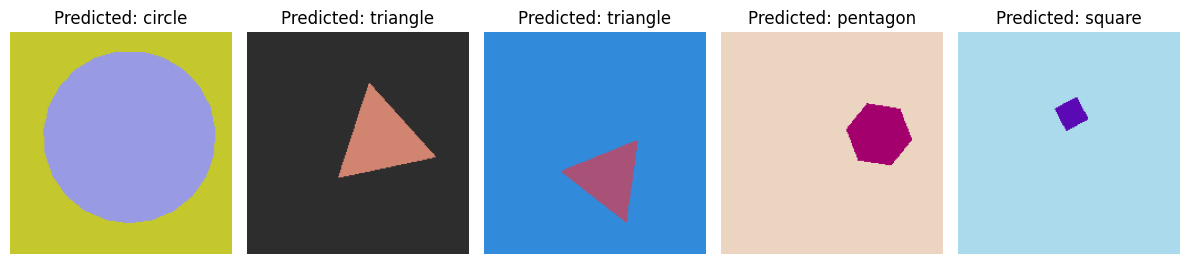

In [ ]:
import cv2
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from joblib import load

# Load the trained Random Forest model and scaler
random_forest_model = load('/content/drive/MyDrive/random_forest_shape_model_with_reduced_features.joblib')
scaler = load('/content/drive/MyDrive/scaler_with_reduced_features.joblib')

# Define shape classes
shape_classes = ['circle', 'hexagon', 'pentagon', 'square', 'triangle']

# Feature extraction functions (same as in training)
def extract_hog_features(image):
    gray_img = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return hog(gray_img, pixels_per_cell=(8, 8), cells_per_block=(2, 2), block_norm='L2-Hys')

def extract_orb_features(image):
    gray_img = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    orb = cv2.ORB_create()
    keypoints, descriptors = orb.detectAndCompute(gray_img, None)
    if descriptors is not None:
        return np.mean(descriptors, axis=0)
    else:
        return np.zeros(32)

def extract_color_histogram(image):
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    hist_hue = cv2.calcHist([hsv], [0], None, [256], [0, 256])
    hist_saturation = cv2.calcHist([hsv], [1], None, [256], [0, 256])
    hist_value = cv2.calcHist([hsv], [2], None, [256], [0, 256])
    hist_hue /= hist_hue.sum()
    hist_saturation /= hist_saturation.sum()
    hist_value /= hist_value.sum()
    return hist_hue.flatten(), hist_saturation.flatten(), hist_value.flatten()

# Function to automatically pick up some example images from the validation dataset
def get_example_images(validation_folder, num_examples=5):
    image_paths = []
    # Traverse the validation folder and get image paths
    for shape_class in shape_classes:
        shape_folder = os.path.join(validation_folder, shape_class)
        if os.path.exists(shape_folder):
            images = [os.path.join(shape_folder, img) for img in os.listdir(shape_folder) if img.endswith(('.png', '.jpg', '.jpeg'))]
            image_paths.extend(images)

    # Randomly select `num_examples` images from the list
    random.shuffle(image_paths)
    return image_paths[:num_examples]

# Define function to predict and display images
def predict_and_display(image_paths, shape_classes):
    if not image_paths:
        print("No images to display.")
        return

    plt.figure(figsize=(12, 8))

    for i, image_path in enumerate(image_paths):
        # Load and preprocess the image
        img = cv2.imread(image_path)

        # Check if the image was loaded correctly
        if img is None:
            print(f"Error: Unable to load image at path {image_path}")
            continue

        img_resized = cv2.resize(img, (60, 60))  # Resizing to 60x60, same as in training

        # Extract features using the same methods as in training
        hog_features = extract_hog_features(img_resized)
        orb_features = extract_orb_features(img_resized)
        hist_hue, hist_saturation, hist_value = extract_color_histogram(img_resized)

        # Combine features
        combined_features = np.concatenate([hog_features, orb_features, hist_hue, hist_saturation, hist_value])

        # Standardize features using the previously fitted scaler
        standardized_features = scaler.transform([combined_features])

        # Predict shape class
        prediction = random_forest_model.predict(standardized_features)[0]
        predicted_label = shape_classes[prediction]

        # Display the image with the prediction
        ax = plt.subplot(1, len(image_paths), i + 1)
        ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))  # Convert BGR to RGB for correct display
        ax.set_title(f'Predicted: {predicted_label}')
        ax.axis('off')  # Hide axes

    plt.tight_layout()
    plt.show()

# Example Usage: Get example images and predict
validation_folder = '/content/drive/MyDrive/smaller datasize'  # Replace with your validation folder path
image_paths = get_example_images(validation_folder, num_examples=5)
predict_and_display(image_paths, shape_classes)


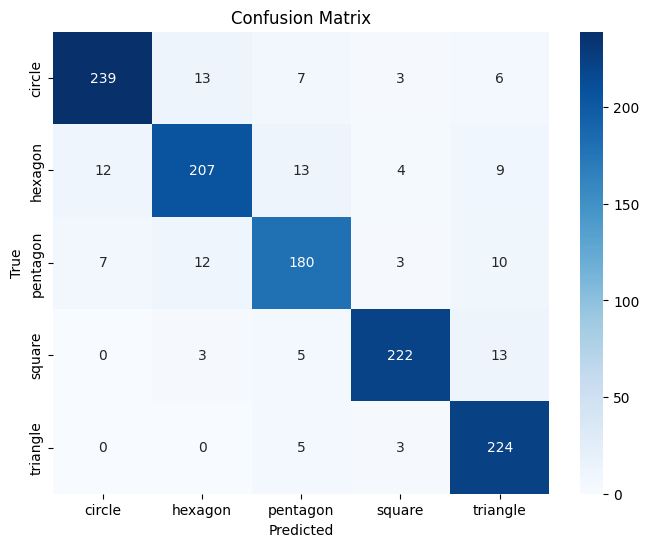

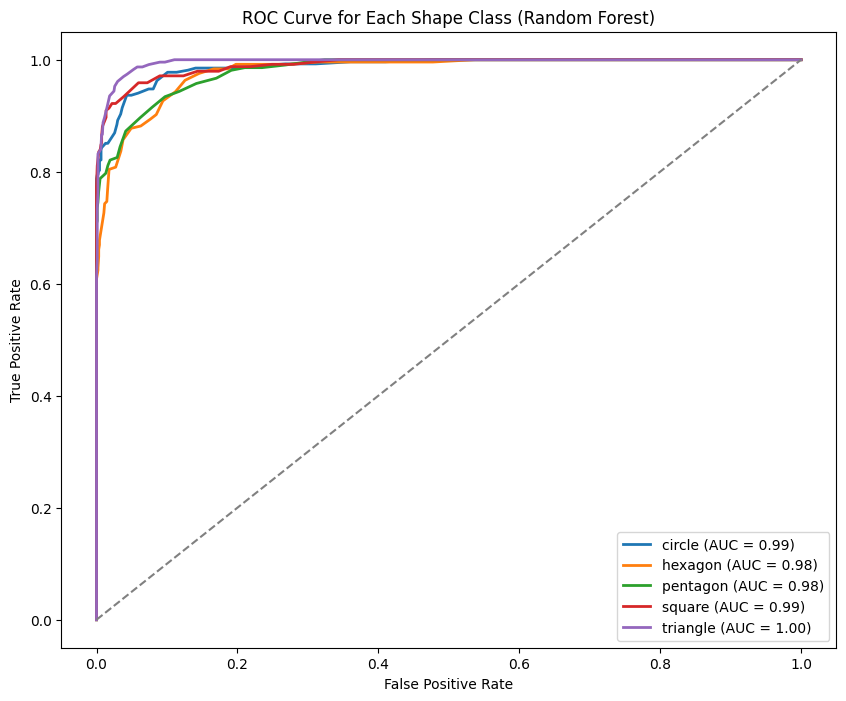

In [ ]:
from sklearn.metrics import confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=shape_classes, yticklabels=shape_classes)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# Binarize the labels for multiclass ROC curve
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3, 4])  # Adjust classes if necessary
y_pred_prob = random_forest_model.predict_proba(X_test)

# Compute ROC curve and ROC area for each class
fpr = {}
tpr = {}
roc_auc = {}

plt.figure(figsize=(10, 8))

for i, shape in enumerate(shape_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_pred_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], lw=2, label=f'{shape} (AUC = {roc_auc[i]:.2f})')

# Plot ROC curve details
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  # Diagonal for reference
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Each Shape Class (Random Forest)')
plt.legend(loc='lower right')
plt.show()


CNN

Found 1201 images belonging to 5 classes.
Found 299 images belonging to 5 classes.
Epoch 1/20


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


37/37 ━━━━━━━━━━━━━━━━━━━━ 21s 472ms/step - accuracy: 0.2487 - loss: 3.2795 - val_accuracy: 0.2396 - val_loss: 1.6005
Epoch 2/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2941 - loss: 2.2614 - val_accuracy: 0.1818 - val_loss: 1.6217
Epoch 3/20


/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


37/37 ━━━━━━━━━━━━━━━━━━━━ 15s 358ms/step - accuracy: 0.4445 - loss: 1.6640 - val_accuracy: 0.2083 - val_loss: 1.6299
Epoch 4/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5312 - loss: 1.2033 - val_accuracy: 0.1818 - val_loss: 1.5331
Epoch 5/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 15s 348ms/step - accuracy: 0.6028 - loss: 0.9919 - val_accuracy: 0.2188 - val_loss: 1.6460
Epoch 6/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.5312 - loss: 1.2603 - val_accuracy: 0.0909 - val_loss: 1.8181
Epoch 7/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 12s 287ms/step - accuracy: 0.7403 - loss: 0.7083 - val_accuracy: 0.2153 - val_loss: 1.6062
Epoch 8/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6562 - loss: 0.8806 - val_accuracy: 0.0909 - val_loss: 1.7861
Epoch 9/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 10s 243ms/step - accuracy: 0.7973 - loss: 0.5492 - val_accuracy: 0.2431 - val_loss: 1.7096
Epoch 10/20
37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6875 - loss: 0.8798 - val_accuracy: 0.3636 - val_lo

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
Accuracy: 27.76%


Predictions on validation images:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step


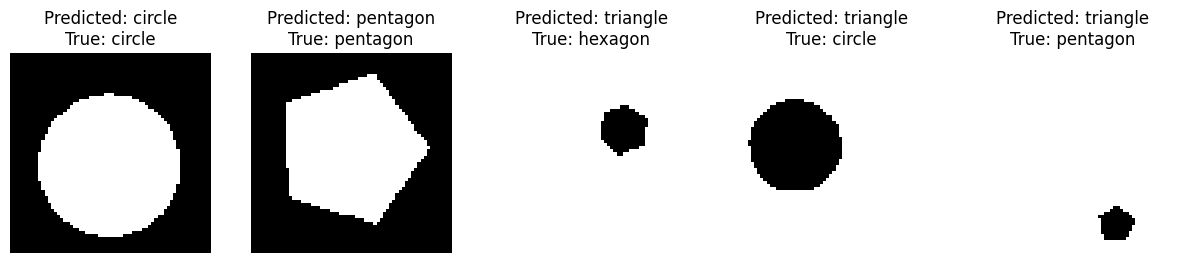

In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, BatchNormalization, Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import accuracy_score
import math

# 1. Define the CNN model
def create_model():
    model = Sequential()
    model.add(Input(shape=(64, 64, 1)))

    # First Convolutional Block
    model.add(Conv2D(16, kernel_size=(3, 3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Second Convolutional Block
    model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Flatten and connect to Dense layers
    model.add(Flatten())
    model.add(Dense(64, activation='relu'))
    model.add(Dense(5, activation='softmax'))  # 5 classes: circle, hexagon, pentagon, square, triangle

    return model

# 2. Prepare data generators for loading the dataset
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = datagen.flow_from_directory(
    '/content/drive/MyDrive/smaller datasize',  # Replace with the path to your dataset
    target_size=(64, 64),
    color_mode='grayscale',
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

validation_generator = datagen.flow_from_directory(
    '/content/drive/MyDrive/smaller datasize',  # Replace with the path to your dataset
    target_size=(64, 64),
    color_mode='grayscale',
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

# 3. Create and compile the model
model = create_model()
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 4. Train the model
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // validation_generator.batch_size,
    epochs=20  # Adjust the number of epochs as necessary
)

# 5. Save the trained model
model.save('shape_detection_model.h5')

# 6. Calculate accuracy on the validation dataset
def calculate_accuracy(generator, model):
    y_true = []
    y_pred = []

    for batch, labels in generator:
        predictions = model.predict(batch)
        y_true.extend(np.argmax(labels, axis=1))
        y_pred.extend(np.argmax(predictions, axis=1))

        if len(y_true) >= generator.samples:
            break

    accuracy = accuracy_score(y_true, y_pred)
    print(f'Accuracy: {accuracy * 100:.2f}%')

# Calculate accuracy on the validation set
calculate_accuracy(validation_generator, model)

# 7. Load the trained model
model = tf.keras.models.load_model('shape_detection_model.h5')

# 8. Function to predict and display a few images from the validation set
def predict_and_show_images(generator, model, num_images=5):
    # Get a batch of images and labels from the generator
    images, labels = next(generator)
    class_labels = list(generator.class_indices.keys())  # Get the class labels

    # Make predictions for the batch
    predictions = model.predict(images)
    predicted_classes = np.argmax(predictions, axis=1)
    true_classes = np.argmax(labels, axis=1)

    # Display each image with the predicted and true labels
    plt.figure(figsize=(15, 5))
    for i in range(num_images):
        plt.subplot(1, num_images, i+1)
        plt.imshow(images[i].reshape(64, 64), cmap='gray')
        predicted_label = class_labels[predicted_classes[i]]
        true_label = class_labels[true_classes[i]]
        plt.title(f"Predicted: {predicted_label}\nTrue: {true_label}")
        plt.axis('off')
    plt.show()

# Predict and display images with predictions from the validation set
print("Predictions on validation images:")
predict_and_show_images(validation_generator, model, num_images=5)


In [ ]:
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
import itertools


In [ ]:
def plot_roc_curve(generator, model, class_labels):
    y_true = []
    y_score = []

    for batch, labels in generator:
        predictions = model.predict(batch)
        y_true.extend(labels)
        y_score.extend(predictions)

        if len(y_true) >= generator.samples:
            break

    y_true = np.array(y_true)
    y_score = np.array(y_score)

    # Plot ROC curve for each class
    plt.figure(figsize=(12, 8))
    for i, class_name in enumerate(class_labels):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f'{class_name} (AUC = {roc_auc:.2f})')

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve for Each Shape Class')
    plt.legend(loc='lower right')
    plt.show()


In [ ]:
def plot_confusion_matrix(generator, model, class_labels):
    y_true = []
    y_pred = []

    for batch, labels in generator:
        predictions = model.predict(batch)
        y_true.extend(np.argmax(labels, axis=1))
        y_pred.extend(np.argmax(predictions, axis=1))

        if len(y_true) >= generator.samples:
            break

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)

    plt.figure(figsize=(10, 8))
    disp.plot(cmap='Blues', values_format='d')
    plt.title("Confusion Matrix for Shape Detection")
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


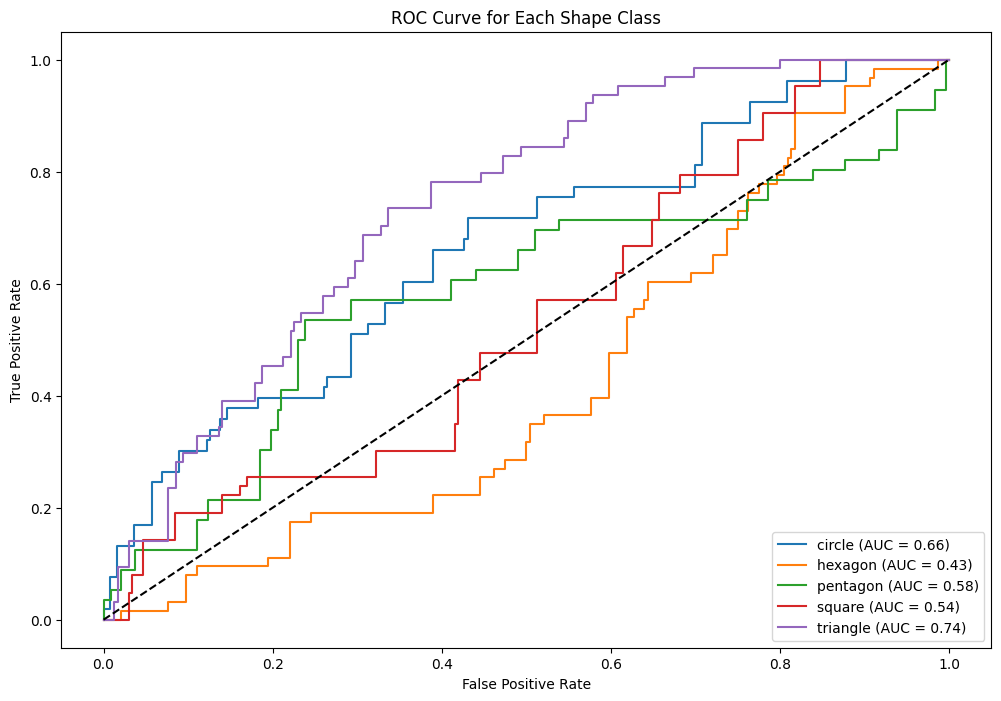

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


<Figure size 1000x800 with 0 Axes>

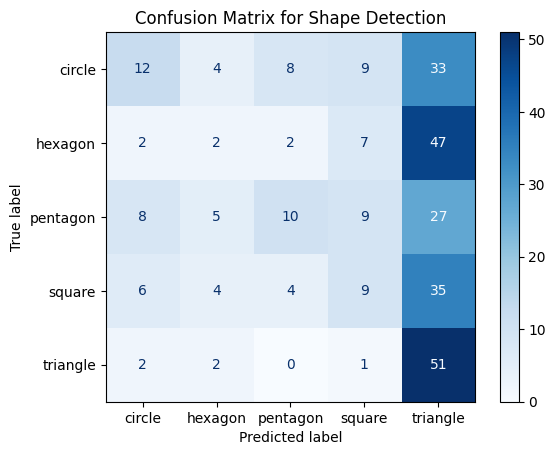

In [ ]:
# Define class labels based on your dataset
class_labels = ['circle', 'hexagon', 'pentagon', 'square', 'triangle']

# Plot ROC curve for the validation set
plot_roc_curve(validation_generator, model, class_labels)

# Plot confusion matrix for the validation set
plot_confusion_matrix(validation_generator, model, class_labels)


# **4-shapes**
(circle,star,triangle,square)

more simpler data without any colors or size differences

this data is obtained from KAGGLE

**Comparision between different models**

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
import seaborn as sns
from tqdm import tqdm
# Set the path for the dataset
data_path = "/content/drive/MyDrive/4-shapes"
def imread(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    return img

def imshow(img, figsize=(5, 5)):
    plt.figure(figsize=figsize)
    plt.imshow(img, cmap='gray')
    plt.show()

def rgb2bin(img_rgb):
    img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    t, img_bin = cv2.threshold(
        img_gray, 0, 255, cv2.THRESH_OTSU|cv2.THRESH_BINARY_INV
    )
    return img_bin
def find_best_contour(img_rgb):
    img_bin = rgb2bin(img_rgb)
    contours, h = cv2.findContours(
        img_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE
    )
    best_contour = max(contours, key=cv2.contourArea)
    return best_contour

def draw_contours(img, contours, index=-1, color=(255, 0, 0), thickness=2):
    img_copy = img.copy()
    cv2.drawContours(img_copy, contours, index, color, thickness)
    imshow(img_copy)

def chain_hist(img_rgb):

    best_contour = find_best_contour(img_rgb)

    lookup_table = {
        (1, 0): 0,
        (1, -1): 1,
        (0, -1): 2,
        (-1, -1): 3,
        (-1, 0): 4,
        (-1, 1): 5,
        (0, 1): 6,
        (1, 1): 7
    }
    hist = np.zeros((8,))
    for i in range(len(best_contour)-1):
        pt1 = best_contour[i][0]
        pt2 = best_contour[i+1][0]
        dx = pt2[0] - pt1[0]
        dy = pt2[1] - pt1[1]
        code = lookup_table[(dx, dy)]
        hist[code] += 1

    return hist/hist.sum()

def create_df(data_path):

    # the class_dict is a mapping between class name and value
    class_dict = {
        'circle': 0,
        'square': 1,
        'star': 2,
        'triangle': 3
    }

    # we store image paths and outputs here
    df = []

    # for each class
    for class_name, class_value in class_dict.items():
        class_folder = os.path.join(data_path, class_name)
        # for each image in class folder
        for f in os.listdir(class_folder):
            f_path = os.path.join(class_folder, f)
            # if this is a "png" file, add its path and output
            if f_path.lower().endswith('.png'):
                df.append([f_path, class_value])

    # create a dataframe of image paths and outputs
    df = pd.DataFrame(df, columns=['path', 'output'])
    return df

def calculate_geometric_features(contour):
    # Calculate the area of the contour
    area = cv2.contourArea(contour)

    # Calculate the perimeter of the contour
    perimeter = cv2.arcLength(contour, True)

    # Calculate the bounding rectangle of the contour
    x, y, w, h = cv2.boundingRect(contour)

    aspect_ratio = float(w) / h

    # Extent is the ratio of contour area to bounding rectangle area
    rect_area = w * h
    extent = float(area) / rect_area

    # Solidity is the ratio of contour area to its convex hull area
    hull = cv2.convexHull(contour)
    hull_area = cv2.contourArea(hull)
    solidity = float(area) / hull_area
    # Circularity relates the area of the contour to its perimeter: 4π*Area / Perimeter^2
    # For a perfect circle, this value should be close to 1
    circularity = (4 * np.pi * area) / (perimeter ** 2) if perimeter != 0 else 0

    # Number of corners (using Harris Corner Detection or approxPolyDP)
    epsilon = 0.01 * perimeter
    approx = cv2.approxPolyDP(contour, epsilon, True)
    num_corners = len(approx)

    return np.array([area, perimeter, aspect_ratio, extent, solidity, circularity, num_corners])
def extract_features(img_paths):
    n = len(img_paths)
    number_of_geometric_features = 7  # From calculate_geometric_features
    X = np.zeros((n, 8 + number_of_geometric_features))

    for i in tqdm(range(n)):
        f_path = img_paths[i]
        img = imread(f_path)
        features = chain_hist(img)
        best_contour = find_best_contour(img)
        geometric_features = calculate_geometric_features(best_contour)
        X[i] = np.concatenate([features, geometric_features])
    return X

def predict(model, img):
    names = ['circle', 'square', 'star', 'triangle']
    # Extract both chain histogram and geometric features
    best_contour = find_best_contour(img)
    chain_features = chain_hist(img)
    geometric_features = calculate_geometric_features(best_contour)
    combined_features = np.concatenate([chain_features, geometric_features]).reshape(1, -1)
    # Use the combined features for prediction
    prediction = model.predict(combined_features)[0]
    return names[prediction]

def detect_connected_components(model, img, width_range, height_range):
    binary_img = rgb2bin(img)
    nLabels, labels, stats, centroids = cv2.connectedComponentsWithStats(binary_img, connectivity=4)
    centroids = centroids.astype(int)
    img_copy = img.copy()
    for i in range(1, nLabels):
        x, y, w, h, _ = stats[i]
        (cx, cy) = centroids[i]
        acceptWidth = width_range[0] < w < width_range[1]
        acceptHeight = height_range[0] < h < height_range[1]
        if acceptWidth and acceptHeight:
            shape = img[y:y+h, x:x+w]
            label = predict(model, shape)  # Use the full_feature_predict function here
            cv2.rectangle(img_copy, (x, y), (x+w, y+h), (255, 0, 0), 2)
            cv2.putText(img_copy, label, (x, y-4), cv2.FONT_HERSHEY_COMPLEX_SMALL, 0.6, (255, 0, 0))
    imshow(img_copy, figsize=(10, 10))

In [ ]:
dataset_path = '/content/drive/MyDrive/4-shapes-20241107T085627Z-001/4-shapes'
df = create_df(dataset_path)
df.head(5)

,path,output
0,/content/drive/MyDrive/4-shapes-20241107T08562...,0
1,/content/drive/MyDrive/4-shapes-20241107T08562...,0
2,/content/drive/MyDrive/4-shapes-20241107T08562...,0
3,/content/drive/MyDrive/4-shapes-20241107T08562...,0
4,/content/drive/MyDrive/4-shapes-20241107T08562...,0


In [ ]:
x= extract_features(df['path'])

y=df['output']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

100%|██████████| 330/330 [01:47<00:00,  3.06it/s]


In [ ]:
x.shape,y.shape

((330, 15), (330,))

In [ ]:
# Define and train models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'SVM': SVC(),
    'XGBoost': XGBClassifier(eval_metric='logloss'),
}

# Lists to store train and test accuracies
train_accuracies = []
test_accuracies = []
# Train and evaluate each model for both training and testing datasets
for name, model in models.items():
    # Train the model
    model.fit(x_train, y_train)

    # Make predictions on both the training and test sets
    train_predictions = model.predict(x_train)
    test_predictions = model.predict(x_test)

    # Calculate the accuracy for both the training and test sets
    train_accuracy = accuracy_score(y_train, train_predictions)
    test_accuracy = accuracy_score(y_test, test_predictions)

    # Append the accuracies to the lists
    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)

    # Print the accuracies
    print(f"{name} - Train Accuracy: {train_accuracy:.4f}, Test Accuracy: {test_accuracy:.4f}")

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression - Train Accuracy: 1.0000, Test Accuracy: 1.0000
Decision Tree - Train Accuracy: 1.0000, Test Accuracy: 0.9848
Random Forest - Train Accuracy: 1.0000, Test Accuracy: 1.0000
SVM - Train Accuracy: 0.7803, Test Accuracy: 0.7879
XGBoost - Train Accuracy: 1.0000, Test Accuracy: 0.9848


<ipython-input-44-f0511921740f>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Algorithm', y='Accuracy Score', data=df, palette='viridis')


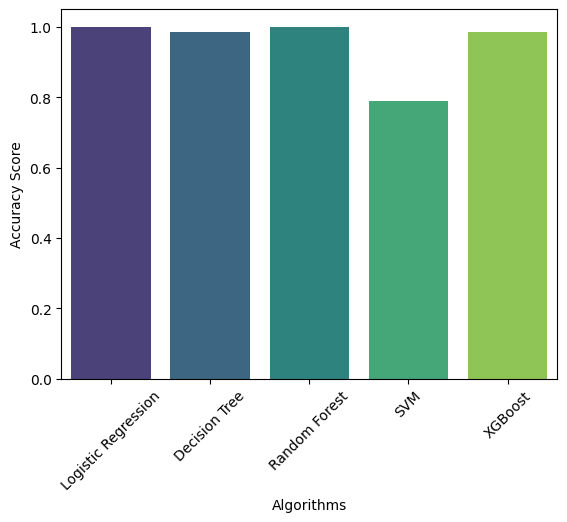

In [ ]:
# Create a dataframe with the algorithm names and their scores
algorithms = list(models.keys())
scores = test_accuracies
df = pd.DataFrame({'Algorithm': algorithms, 'Accuracy Score': scores})

# Set the figure size and labels for the barplot
sns.set_style(rc={'figure.figsize': (12, 8)})
plt.xlabel("Algorithms")
plt.ylabel("Accuracy Score")

# Create the barplot
sns.barplot(x='Algorithm', y='Accuracy Score', data=df, palette='viridis')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



Epoch 1/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 612ms/step - accuracy: 0.2370 - loss: 1.3927 - val_accuracy: 0.4737 - val_loss: 1.3459
Epoch 2/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 648ms/step - accuracy: 0.3588 - loss: 1.3499 - val_accuracy: 0.6316 - val_loss: 1.2995
Epoch 3/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 296ms/step - accuracy: 0.3071 - loss: 1.3408 - val_accuracy: 0.6842 - val_loss: 1.2166
Epoch 4/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 296ms/step - accuracy: 0.3850 - loss: 1.2488 - val_accuracy: 0.6842 - val_loss: 1.0253
Epoch 5/5
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 296ms/step - accuracy: 0.4790 - loss: 1.1008 - val_accuracy: 0.7632 - val_loss: 0.7894
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.6357 - loss: 0.7726 
Accuracy is 63.85542154312134%
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step


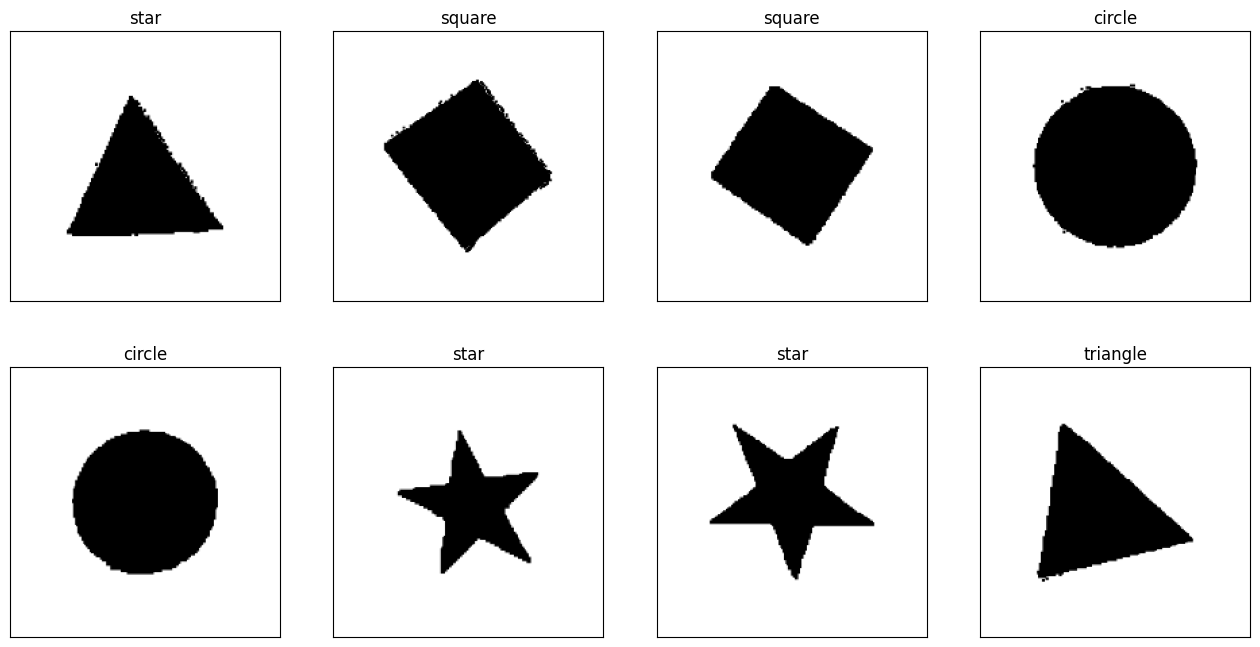

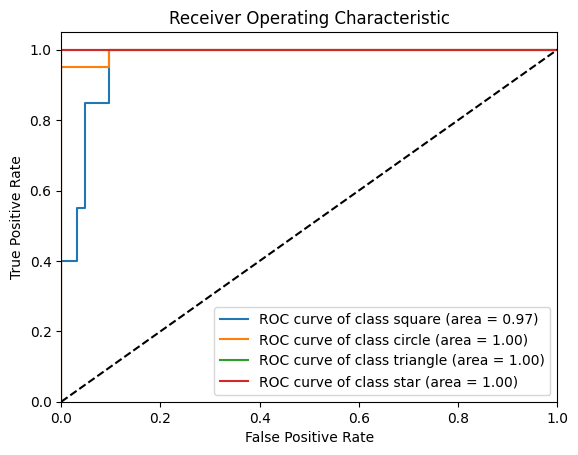

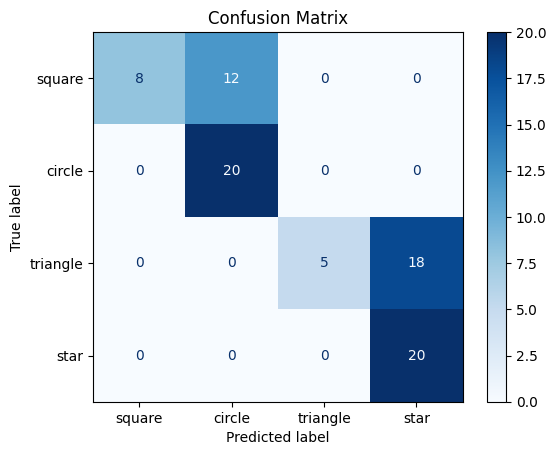

In [ ]:
import tensorflow as tf
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

from tensorflow.keras.layers import Conv2D, Flatten, MaxPooling2D, Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
import plotly.express as px
from plotly import offline
offline.init_notebook_mode(connected = True)

BASE_DIR = '/content/drive/MyDrive/4-shapes-20241107T085627Z-001/4-shapes'
shapes = os.listdir(BASE_DIR)
shapes

data = []
target = []

for i, shape in enumerate(shapes):
    path = os.path.join(BASE_DIR, shape)
    for filename in os.listdir(path):
        image = cv2.imread(os.path.join(path , filename), 0)
        image = image.reshape(200, 200, 1)
        data.append(image)
        target.append(i)

data = np.array(data)
target = np.array(target)
target = to_categorical(target)
data.shape, target.shape

X_full, X_test, y_full, y_test = train_test_split(data, target, stratify=target, random_state=42, test_size=0.25)
X_train, X_val, y_train, y_val = train_test_split(X_full, y_full, stratify=y_full, random_state=42, test_size=0.15)
X_test = X_test / 255.0
X_train = X_train / 255.0
X_val = X_val / 255.0

model = Sequential([
    Conv2D(32, (3, 3), strides=2, input_shape=(200, 200, 1), activation='relu'),
    MaxPooling2D(),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(),
    Conv2D(32, (3, 3), activation='relu'),
    MaxPooling2D(),
    Flatten(),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=5, validation_data=(X_val, y_val))
metrics = pd.DataFrame(history.history)
px.line(metrics)

loss, accuracy = model.evaluate(X_test, y_test)
print('Accuracy is {}%'.format(accuracy * 100))

def show_images(count, X, y):
    fig, axes = plt.subplots(count // 4, 4, figsize=(16, count))
    for i, ind in enumerate(np.random.randint(0, X.shape[0], count)):
        ax = axes[i // 4][i % 4]
        ax.imshow(X[ind], cmap='gray')
        ax.title.set_text(shapes[np.argmax(y[ind])])
        ax.set_xticks([])
        ax.set_yticks([])

preds = model.predict(X_test)
show_images(8, X_test, preds)

# ROC Curve
fpr = {}
tpr = {}
roc_auc = {}

for i in range(len(shapes)):
    fpr[i], tpr[i], _ = roc_curve(y_test[:, i], preds[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure()
for i in range(len(shapes)):
    plt.plot(fpr[i], tpr[i], label=f'ROC curve of class {shapes[i]} (area = {roc_auc[i]:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# Confusion Matrix
y_pred_classes = np.argmax(preds, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

cm = confusion_matrix(y_true_classes, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=shapes)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()